In [3]:
#Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#Carregando o dataset
df = pd.read_csv('C:/Users/Usuario/Documents/Estudos CD/ecommerce-customer-churn-analysis/data/raw/Customer_Churn_Dataset.csv')

In [14]:
#Avaliação inicial do dataset
df.shape # linhas e colunas
df.head() # primeiras linhas do dataset
df.info() # informações sobre o dataset
df.describe() # estatísticas descritivas
df.isnull().sum() # verificando valores nulos
df.duplicated().sum() # verificando valores duplicados

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


np.int64(0)

<Axes: xlabel='Churn', ylabel='count'>

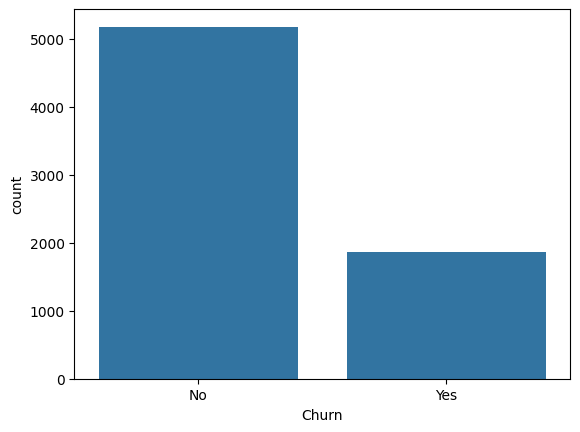

In [15]:
#gráfico em barras para a variável alvo
df["Churn"].value_counts() #contar de cada classe
df["Churn"].value_counts(normalize=True) * 100 #entrega em porcentagem
sns.countplot(x="Churn",data=df) #grafico em barras

<Axes: ylabel='TotalCharges'>

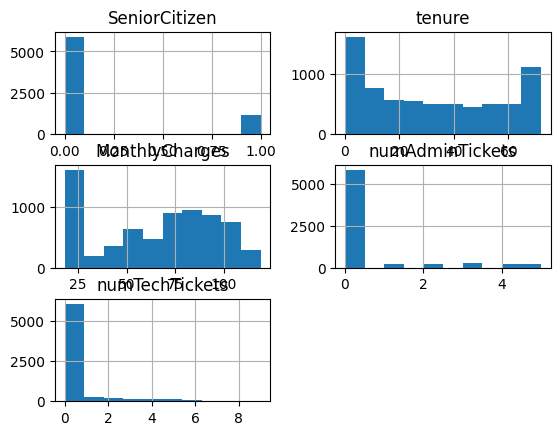

In [16]:
#analise de variáveis numéricas
numericas = df.select_dtypes(include=['int64', 'float64']).columns # seleciona apenas as colunas numéricas
df[numericas].describe() # estatísticas descritivas para variáveis numéricas
df[numericas].hist() # histograma para cada variável numérica
sns.boxplot(y='TotalCharges', data=df) # boxplot para identificar outliers na variável TotalCharges

<Axes: xlabel='count', ylabel='PaymentMethod'>

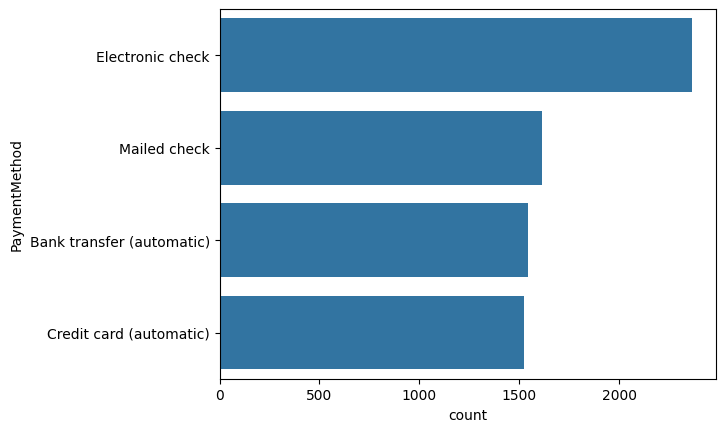

In [20]:
#Análise de variáveis categóricas
categoricas = df.select_dtypes(include=['object']).columns # seleciona apenas as colunas categóricas
df["PaymentMethod"].value_counts() # contagem de cada categoria na variável PaymentMethod
df['PaymentMethod'].value_counts(normalize=True) * 100 # porcentagem de cada categoria na variável PaymentMethod
sns.countplot(y='PaymentMethod', data=df) # boxplot para identificar a distribuição da variável PaymentMethod

In [24]:
#Coerência lógica e problemas
(df["TotalCharges"]== df["MonthlyCharges"]*df["tenure"]).value_counts() # verificando a coerência lógica entre TotalCharges, MonthlyCharges e tenure
df[df['TotalCharges'].isnull()] # verificando os registros onde TotalCharges é nulo


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn


<Axes: >

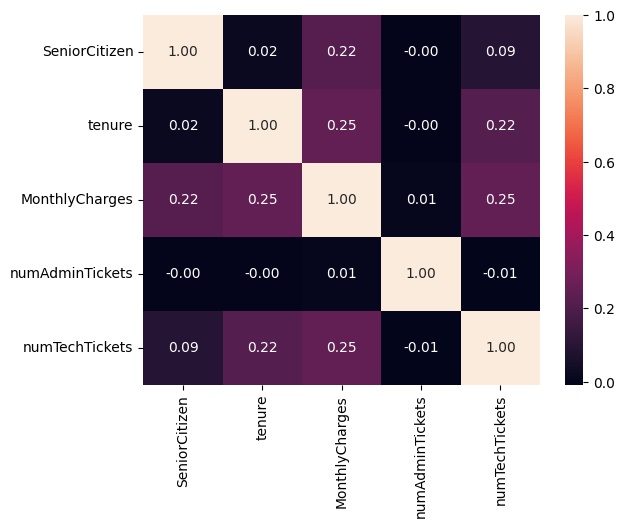

In [13]:
# Análise de correlação
corr = df[numericas].corr() # matriz de correlação para variáveis numéricas
sns.heatmap(corr, annot=True, fmt=".2f") # heatmap para visualizar a correlação entre variáveis numéricas